In [ ]:
# Phase 1: Install Required Libraries
!pip install -q torch torchvision transformers opencv-python albumentations matplotlib seaborn datasets gdown

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("putriaziza/deepguarddb-v1")

print("Path to dataset files:", path)

100%|██████████| 1.51G/1.51G [00:20<00:00, 77.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1


In [ ]:
# Explore DeepGuardDB Dataset Structure
import os

base_path = path
print(f"Dataset root: {base_path}")
print(f"Root contents: {os.listdir(base_path)}")

total_images = 0
for root, dirs, files in os.walk(base_path):
    if files:
        img_count = len([f for f in files if f.endswith(('.jpg', '.png', '.jpeg'))])
        if img_count > 0:
            print(f"\nFolder: {root}")
            print(f"Images: {img_count}")
        total_images += img_count

print(f"\nTotal images found: {total_images}")

Dataset root: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1
Root contents: ['DeepGuardDB_v1']

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/IMAGEN_dataset/fake
Images: 997

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/IMAGEN_dataset/real
Images: 1175

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/SD_dataset/fake
Images: 2675

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/SD_dataset/real
Images: 2675

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/DALLE_dataset/fake
Images: 1480

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/DALLE_dataset/real
Images: 2150

Folder: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/GLIDE_dataset/fake
Images: 500

Folder: /root

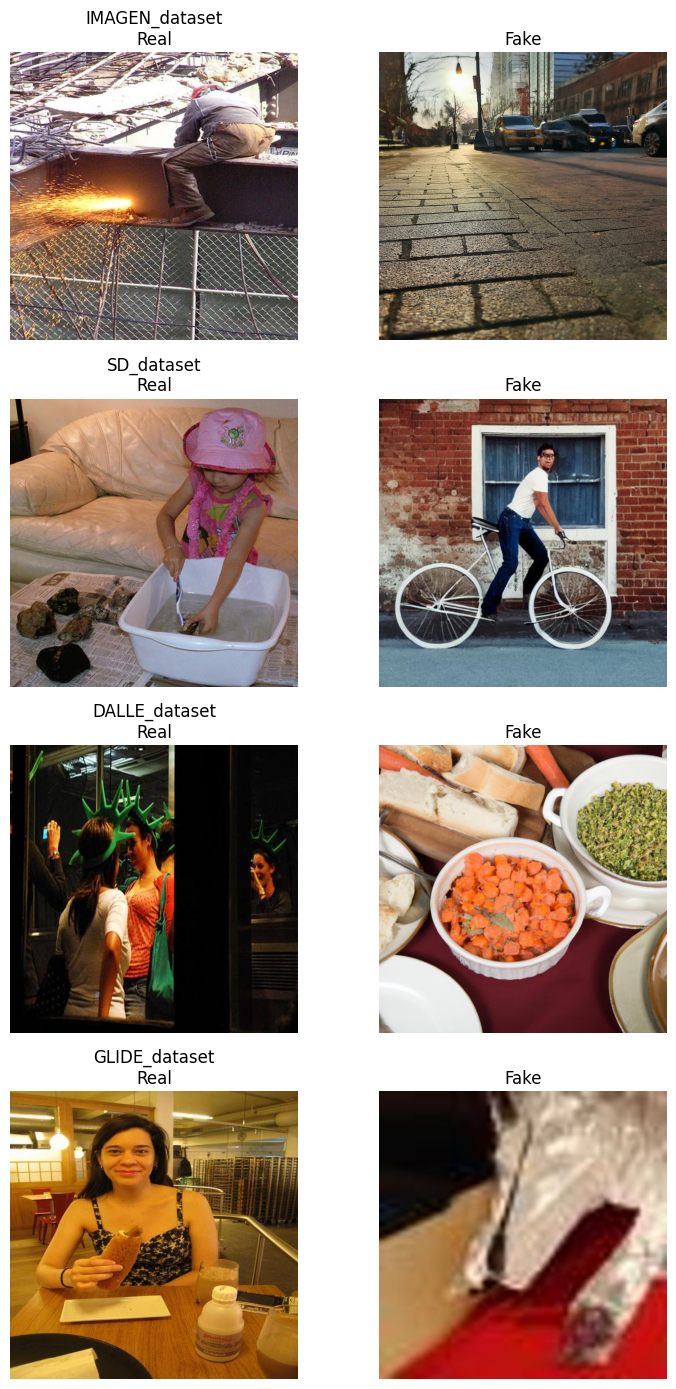

Dataset visualization complete
Generators: IMAGEN_dataset, SD_dataset, DALLE_dataset, GLIDE_dataset


In [ ]:
# Exploratory Data Analysis and Sample Visualization
import matplotlib.pyplot as plt
from PIL import Image
import random

base = "/root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1"

generators = ["IMAGEN_dataset", "SD_dataset", "DALLE_dataset", "GLIDE_dataset"]

fig, axes = plt.subplots(len(generators), 2, figsize=(8, 14))

for i, gen in enumerate(generators):
    real_path = os.path.join(base, gen, "real")
    fake_path = os.path.join(base, gen, "fake")

    real_img = Image.open(os.path.join(real_path, random.choice(os.listdir(real_path)))).convert("RGB")
    fake_img = Image.open(os.path.join(fake_path, random.choice(os.listdir(fake_path)))).convert("RGB")

    axes[i, 0].imshow(real_img)
    axes[i, 0].set_title(f"{gen}\nReal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(fake_img)
    axes[i, 1].set_title(f"Fake")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

print("Dataset visualization complete")
print(f"Generators: {', '.join(generators)}")

In [ ]:
# Phase 2: Data Preprocessing - Augmentation Pipeline
import albumentations as A
from albumentations.pytorch import ToTensorV2

image_size = 224
batch_size = 32

train_transforms = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.ImageCompression(quality_lower=30, quality_upper=90, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("Augmentation pipeline ready")
print(f"Image size: {image_size}x{image_size}, Batch size: {batch_size}")

Augmentation pipeline ready
Image size: 224x224, Batch size: 32


/tmp/ipykernel_6520/1937506091.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
/tmp/ipykernel_6520/1937506091.py:14: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=30, quality_upper=90, p=0.3),


In [ ]:
# Create PyTorch Dataset Class
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class DeepGuardDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        generators = ["IMAGEN_dataset", "SD_dataset", "DALLE_dataset", "GLIDE_dataset"]

        for gen in generators:
            real_path = os.path.join(root_dir, gen, "real")
            fake_path = os.path.join(root_dir, gen, "fake")

            for img_name in os.listdir(real_path):
                self.images.append(os.path.join(real_path, img_name))
                self.labels.append(0)

            for img_name in os.listdir(fake_path):
                self.images.append(os.path.join(fake_path, img_name))
                self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image=np.array(image))["image"]
        return image, label

In [ ]:
# Create DataLoader Objects with Train/Val/Test Splits
from torch.utils.data import DataLoader, Subset

dataset = DeepGuardDataset(base, transform=train_transforms)

dataset_size = len(dataset)
val_size = int(0.15 * dataset_size)
test_size = int(0.15 * dataset_size)
train_size = dataset_size - val_size - test_size

indices = np.arange(dataset_size)
np.random.seed(42)
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Total: {dataset_size} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

Total: 13000 | Train: 9100 | Val: 1950 | Test: 1950


In [ ]:
# Phase 3: Load Pretrained CLIP-ViT Model
import torch.nn as nn
from transformers import CLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

for param in clip_model.parameters():
    param.requires_grad = False

for param in clip_model.vision_model.encoder.layers[-4:].parameters():
    param.requires_grad = True

print(f"CLIP-ViT-B/32 loaded on {device}")
print("Early layers frozen, last 4 encoder layers trainable")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP-ViT-B/32 loaded on cuda
Early layers frozen, last 4 encoder layers trainable


In [ ]:
# Verify Frozen and Trainable Layers
frozen = sum(1 for p in clip_model.parameters() if not p.requires_grad)
trainable = sum(1 for p in clip_model.parameters() if p.requires_grad)
print(f"Frozen: {frozen}, Trainable: {trainable}")

Frozen: 334, Trainable: 64


In [ ]:
# Build AIDE Branch with Custom Classification Head
class AIDEBranch(nn.Module):
    def __init__(self, clip_model, feature_dim=512, num_classes=2):
        super(AIDEBranch, self).__init__()
        self.clip_vision = clip_model.vision_model
        self.fc1 = nn.Linear(768, feature_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(feature_dim, feature_dim)
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        features = self.clip_vision(x).last_hidden_state[:, 0, :]
        x = self.fc1(features)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits, features

aide_model = AIDEBranch(clip_model).to(device)
print("AIDE Branch with custom classification head created")

AIDE Branch with custom classification head created


In [ ]:
# Train AIDE Branch
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(aide_model.parameters(), lr=1e-5)

num_epochs = 15
best_val_acc = 0

print(f"Training AIDE Branch | LR: 1e-5 | Epochs: {num_epochs}")
print("-" * 55)

for epoch in range(num_epochs):
    aide_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = aide_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    aide_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = aide_model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(aide_model.state_dict(), "aide_branch_best.pth")
        print(f"Saved — Best Val Acc: {best_val_acc:.2f}%")

print(f"\nTraining complete. Best Val Acc: {best_val_acc:.2f}%")

Training AIDE Branch | LR: 1e-5 | Epochs: 15
-------------------------------------------------------
Epoch 01/15 | Train Loss: 0.2324 | Train Acc: 91.37% | Val Acc: 97.13%
Saved — Best Val Acc: 97.13%
Epoch 02/15 | Train Loss: 0.0440 | Train Acc: 98.52% | Val Acc: 97.44%
Saved — Best Val Acc: 97.44%
Epoch 03/15 | Train Loss: 0.0264 | Train Acc: 99.16% | Val Acc: 97.59%
Saved — Best Val Acc: 97.59%
Epoch 04/15 | Train Loss: 0.0110 | Train Acc: 99.62% | Val Acc: 97.64%
Saved — Best Val Acc: 97.64%
Epoch 05/15 | Train Loss: 0.0096 | Train Acc: 99.67% | Val Acc: 96.72%
Epoch 06/15 | Train Loss: 0.0030 | Train Acc: 99.93% | Val Acc: 97.85%
Saved — Best Val Acc: 97.85%
Epoch 07/15 | Train Loss: 0.0005 | Train Acc: 99.99% | Val Acc: 97.90%
Saved — Best Val Acc: 97.90%
Epoch 08/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Acc: 97.85%


KeyboardInterrupt: 

In [ ]:
# Retrain AIDE with Better Regularization
class AIDEBranch(nn.Module):
    def __init__(self, clip_model, feature_dim=512, num_classes=2):
        super(AIDEBranch, self).__init__()
        self.clip_vision = clip_model.vision_model
        self.fc1 = nn.Linear(768, feature_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(feature_dim, feature_dim)
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        features = self.clip_vision(x).last_hidden_state[:, 0, :]
        x = self.fc1(features)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits, features

# Unfreeze only last 2 layers instead of 4
for param in clip_model.parameters():
    param.requires_grad = False
for param in clip_model.vision_model.encoder.layers[-2:].parameters():
    param.requires_grad = True

aide_model = AIDEBranch(clip_model).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(aide_model.parameters(), lr=5e-6)

In [ ]:
# Retrain AIDE with Better Regularization - 5 Epochs
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(aide_model.parameters(), lr=5e-6)

num_epochs = 3
best_val_acc = 0

print(f"Retraining AIDE | LR: 5e-6 | Epochs: {num_epochs}")
print("-" * 55)

for epoch in range(num_epochs):
    aide_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = aide_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    aide_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = aide_model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(aide_model.state_dict(), "aide_branch_best.pth")
        print(f"Saved — Best Val Acc: {best_val_acc:.2f}%")

print(f"\nBest Val Acc: {best_val_acc:.2f}%")

Retraining AIDE | LR: 5e-6 | Epochs: 3
-------------------------------------------------------
Epoch 1/3 | Train Loss: 0.1040 | Train Acc: 96.98% | Val Acc: 97.95%
Saved — Best Val Acc: 97.95%
Epoch 2/3 | Train Loss: 0.0020 | Train Acc: 100.00% | Val Acc: 97.90%
Epoch 3/3 | Train Loss: 0.0005 | Train Acc: 100.00% | Val Acc: 97.69%

Best Val Acc: 97.95%


In [ ]:
# Define and Run Diagnostic Test
def quick_test(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(image).unsqueeze(0).to(device)

    aide_model.load_state_dict(torch.load("aide_branch_best.pth"))
    aide_model.eval()

    with torch.no_grad():
        logits, _ = aide_model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    labels = ["Real", "Fake"]
    print(f"Real: {logits[0][0]:.4f} | Fake: {logits[0][1]:.4f}")
    print(f"Prediction: {labels[pred]} ({probs[0][pred]*100:.1f}%)")

import random
sample_real = random.choice([dataset.images[i] for i in train_indices if dataset.labels[i] == 0])
quick_test(sample_real)
print(f"Image: {sample_real}")

sample_fake = random.choice([dataset.images[i] for i in train_indices if dataset.labels[i] == 1])
quick_test(sample_fake)
print(f"Image: {sample_fake}")

Real: 3.4583 | Fake: -2.9189
Prediction: Real (99.8%)
Image: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/IMAGEN_dataset/real/8037906430.jpg
Real: -5.8497 | Fake: 4.1207
Prediction: Fake (100.0%)
Image: /root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1/SD_dataset/fake/Image_sd2 90.jpg


In [ ]:
# Phase 4: NPR Branch Implementation
import torch.nn as nn
import torch.nn.functional as F

class NPRBranch(nn.Module):
    def __init__(self, feature_dim=256, num_classes=2):
        super(NPRBranch, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, feature_dim)
        self.dropout = nn.Dropout(0.3)

    def local_patch_correlation(self, x, patch_size=5):
        unfolded = F.unfold(x, kernel_size=patch_size, padding=patch_size//2)
        unfolded = unfolded.view(x.size(0), 3, patch_size*patch_size, -1)
        mean_vals = unfolded.mean(dim=2, keepdim=True)
        centered = unfolded - mean_vals
        cov = (centered @ centered.transpose(2, 3)) / (patch_size*patch_size - 1)
        return cov.mean(dim=3)

    def forward(self, x):
        correlation_features = self.local_patch_correlation(x)
        correlation_features = correlation_features.view(x.size(0), 3, -1, 1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = self.dropout(x)
        return x

npr_model = NPRBranch().to(device)
print("NPR Branch with local patch correlation created")

NPR Branch with local patch correlation created


In [ ]:
# Train NPR Branch
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(npr_model.parameters(), lr=1e-3)

num_epochs = 10
best_val_acc = 0

print(f"Training NPR Branch | LR: 1e-3 | Epochs: {num_epochs}")
print("-" * 55)

for epoch in range(num_epochs):
    npr_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        features = npr_model(images)
        loss = criterion(features, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(features, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    npr_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            features = npr_model(images)
            _, predicted = torch.max(features, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(npr_model.state_dict(), "npr_branch_best.pth")
        print(f"Saved — Best Val Acc: {best_val_acc:.2f}%")

print(f"\nBest Val Acc: {best_val_acc:.2f}%")

Training NPR Branch | LR: 1e-3 | Epochs: 10
-------------------------------------------------------
Epoch 01/10 | Train Loss: 2.1869 | Train Acc: 52.10% | Val Acc: 53.90%
Saved — Best Val Acc: 53.90%
Epoch 02/10 | Train Loss: 2.0744 | Train Acc: 53.88% | Val Acc: 63.18%
Saved — Best Val Acc: 63.18%
Epoch 03/10 | Train Loss: 2.0394 | Train Acc: 56.67% | Val Acc: 69.49%
Saved — Best Val Acc: 69.49%
Epoch 04/10 | Train Loss: 1.9810 | Train Acc: 60.03% | Val Acc: 72.72%
Saved — Best Val Acc: 72.72%
Epoch 05/10 | Train Loss: 1.9309 | Train Acc: 61.04% | Val Acc: 75.59%
Saved — Best Val Acc: 75.59%
Epoch 06/10 | Train Loss: 1.9222 | Train Acc: 61.49% | Val Acc: 73.38%
Epoch 07/10 | Train Loss: 1.8876 | Train Acc: 62.65% | Val Acc: 75.44%
Epoch 08/10 | Train Loss: 1.9094 | Train Acc: 62.10% | Val Acc: 75.13%
Epoch 09/10 | Train Loss: 1.9031 | Train Acc: 61.99% | Val Acc: 76.72%
Saved — Best Val Acc: 76.72%
Epoch 10/10 | Train Loss: 1.8703 | Train Acc: 63.27% | Val Acc: 74.46%

Best Val Acc: 7

In [ ]:
# Load Best NPR Model Checkpoint
npr_model.load_state_dict(torch.load("npr_branch_best.pth"))
npr_model.eval()

test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        features = npr_model(images)
        _, predicted = torch.max(features, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"NPR Test Accuracy: {test_acc:.2f}%")

NPR Test Accuracy: 77.18%


In [ ]:
# Phase 5: Ensemble Integration - Load Both Branches
aide_model.load_state_dict(torch.load("aide_branch_best.pth"))
npr_model.load_state_dict(torch.load("npr_branch_best.pth"))

aide_model.eval()
npr_model.eval()

print("AIDE and NPR branches loaded and ready for ensemble")

AIDE and NPR branches loaded and ready for ensemble


In [ ]:
# Freeze Both Branches for Ensemble Training
for param in aide_model.parameters():
    param.requires_grad = False

for param in npr_model.parameters():
    param.requires_grad = False

print("Both branches frozen")
print("Only ensemble classifier head will be trained")

Both branches frozen
Only ensemble classifier head will be trained


In [ ]:
# Extract and Concatenate Features from Both Branches
def get_combined_features(aide_model, npr_model, x):
    with torch.no_grad():
        _, aide_features = aide_model(x)
        npr_features = npr_model(x)
    combined = torch.cat([aide_features, npr_features], dim=1)
    return combined

sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)
combined = get_combined_features(aide_model, npr_model, sample_batch)
print(f"AIDE features: {combined.shape[1] - 256}")
print(f"NPR features: 256")
print(f"Combined features: {combined.shape[1]}")

AIDE features: 768
NPR features: 256
Combined features: 1024


In [ ]:
# Build Ensemble Classifier Head
class EnsembleClassifier(nn.Module):
    def __init__(self, input_dim=1024, num_classes=2):
        super(EnsembleClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

ensemble_head = EnsembleClassifier().to(device)
print("Ensemble classifier head created")
print(f"Input: 1024 | Hidden: 256, 128 | Output: 2")

Ensemble classifier head created
Input: 1024 | Hidden: 256, 128 | Output: 2


In [ ]:
# Train Ensemble Head with Frozen Branches
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ensemble_head.parameters(), lr=1e-4)

num_epochs = 10
best_val_acc = 0

print(f"Training Ensemble Head | LR: 1e-4 | Epochs: {num_epochs}")
print("-" * 55)

for epoch in range(num_epochs):
    ensemble_head.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        combined = get_combined_features(aide_model, npr_model, images)
        outputs = ensemble_head(combined)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    ensemble_head.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            combined = get_combined_features(aide_model, npr_model, images)
            outputs = ensemble_head(combined)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ensemble_head.state_dict(), "ensemble_head_best.pth")
        print(f"Saved — Best Val Acc: {best_val_acc:.2f}%")

print(f"\nBest Val Acc: {best_val_acc:.2f}%")

Training Ensemble Head | LR: 1e-4 | Epochs: 10
-------------------------------------------------------
Epoch 01/10 | Train Loss: 0.0089 | Train Acc: 99.81% | Val Acc: 98.10%
Saved — Best Val Acc: 98.10%
Epoch 02/10 | Train Loss: 0.0002 | Train Acc: 100.00% | Val Acc: 98.10%
Epoch 03/10 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Acc: 98.10%
Epoch 04/10 | Train Loss: 0.0002 | Train Acc: 99.98% | Val Acc: 98.10%


KeyboardInterrupt: 

In [ ]:
# Load Best Frozen Ensemble
aide_model.load_state_dict(torch.load("aide_branch_best.pth"))
npr_model.load_state_dict(torch.load("npr_branch_best.pth"))
ensemble_head.load_state_dict(torch.load("ensemble_head_best.pth"))
print("Best model: 98.10% restored")

Best model: 98.10% restored


In [ ]:
import cv2
import numpy as np
import torch

# Fixed Grad-CAM for CLIP-ViT Architecture
def grad_cam_aide(model, image_tensor, target_layer):
    gradients = []
    activations = []

    def save_gradient(grad):
        gradients.append(grad)

    def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

    hook = target_layer.register_forward_hook(forward_hook)
    logits, _ = model(image_tensor)
    pred_class = logits.argmax(dim=1).item()
    logits[0, pred_class].backward()
    hook.remove()

    grad = gradients[0]  # Shape: [1, 50, 768] (for ViT-B/32, 49 patches + 1 class token)
    act = activations[0]  # Shape: [1, 50, 768]

    weights = grad.mean(dim=1, keepdim=True)  # [1, 1, 768]
    cam = (weights * act).mean(dim=2)  # [1, 50]

    # Remove the class token and reshape to the correct patch grid (7x7 for ViT-B/32)
    cam = cam[:, 1:] # Remove class token, shape becomes [1, 49]
    cam = cam.reshape(7, 7).detach().cpu().numpy() # Reshape to 7x7
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam /= cam.max() if cam.max() != 0 else 1
    return cam, pred_class

target_layer = aide_model.clip_vision.encoder.layers[-1]
sample_img, _ = next(iter(val_loader))
sample_img = sample_img[0:1].to(device)
sample_img.requires_grad = True

heatmap, pred = grad_cam_aide(aide_model, sample_img, target_layer)
print(f"Grad-CAM ready | Predicted: {'Fake' if pred == 1 else 'Real'}")
print(f"Heatmap shape: {heatmap.shape}")

Grad-CAM ready | Predicted: Real
Heatmap shape: (224, 224)


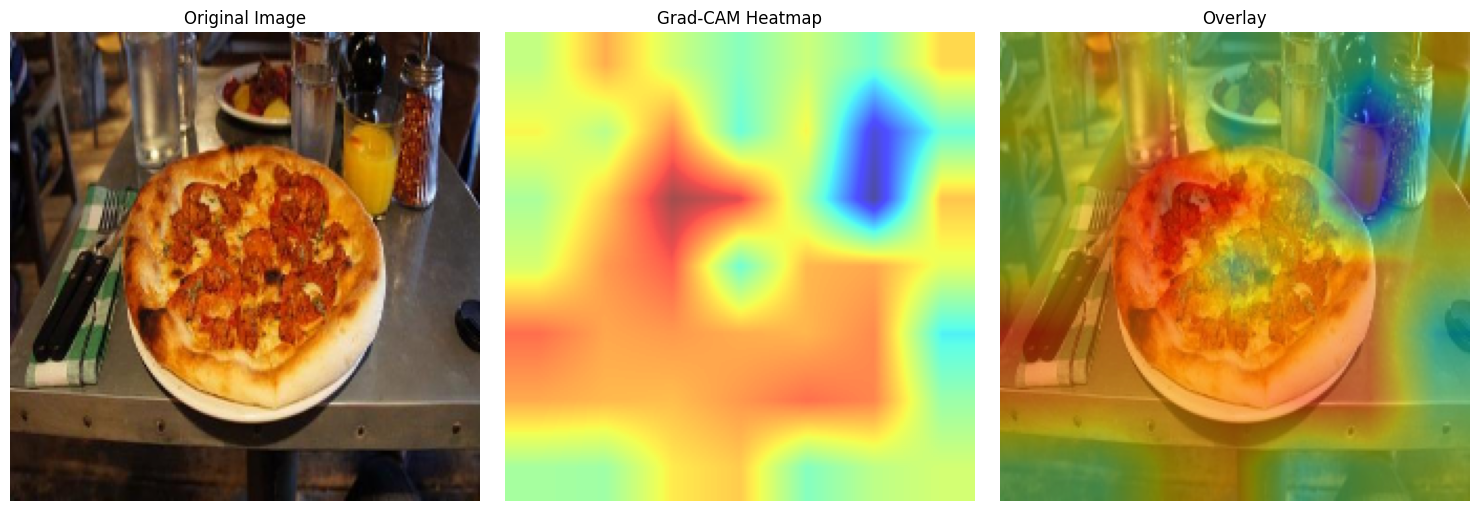

In [ ]:
# Visualize Grad-CAM Heatmap on Image
import matplotlib.pyplot as plt

def show_grad_cam(image_tensor, heatmap):
    img = image_tensor[0].cpu().detach().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap='jet', alpha=0.7)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(img)
    axes[2].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

show_grad_cam(sample_img, heatmap)

NPR correlation heatmap shape: (5, 5)


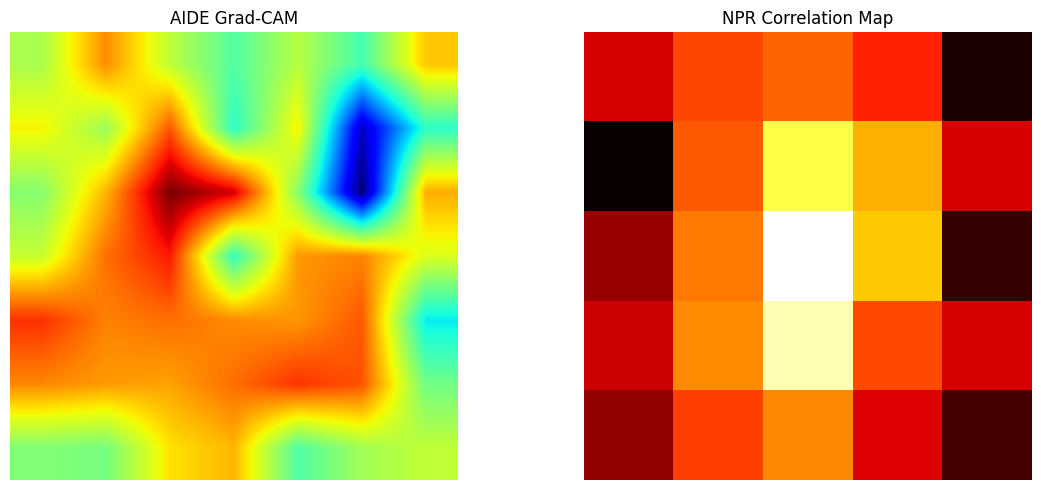

In [ ]:
# Generate NPR Correlation Heatmaps
def npr_correlation_heatmap(model, image_tensor, patch_size=5):
    with torch.no_grad():
        unfolded = F.unfold(image_tensor, kernel_size=patch_size, padding=patch_size//2)
        unfolded = unfolded.view(1, 3, patch_size*patch_size, -1)
        mean_vals = unfolded.mean(dim=2, keepdim=True)
        centered = unfolded - mean_vals
        cov = (centered @ centered.transpose(2, 3)) / (patch_size*patch_size - 1)
        corr = cov.squeeze(0).mean(dim=0)
        corr_map = corr.mean(dim=0).cpu().numpy()
        corr_map = corr_map.reshape(int(np.sqrt(corr_map.shape[0])), -1)
        corr_map = (corr_map - corr_map.min()) / (corr_map.max() - corr_map.min() + 1e-8)
    return corr_map

corr_heatmap = npr_correlation_heatmap(npr_model, sample_img)
print(f"NPR correlation heatmap shape: {corr_heatmap.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(heatmap, cmap='jet')
axes[0].set_title("AIDE Grad-CAM")
axes[0].axis("off")
axes[1].imshow(corr_heatmap, cmap='hot')
axes[1].set_title("NPR Correlation Map")
axes[1].axis("off")
plt.tight_layout()
plt.show()

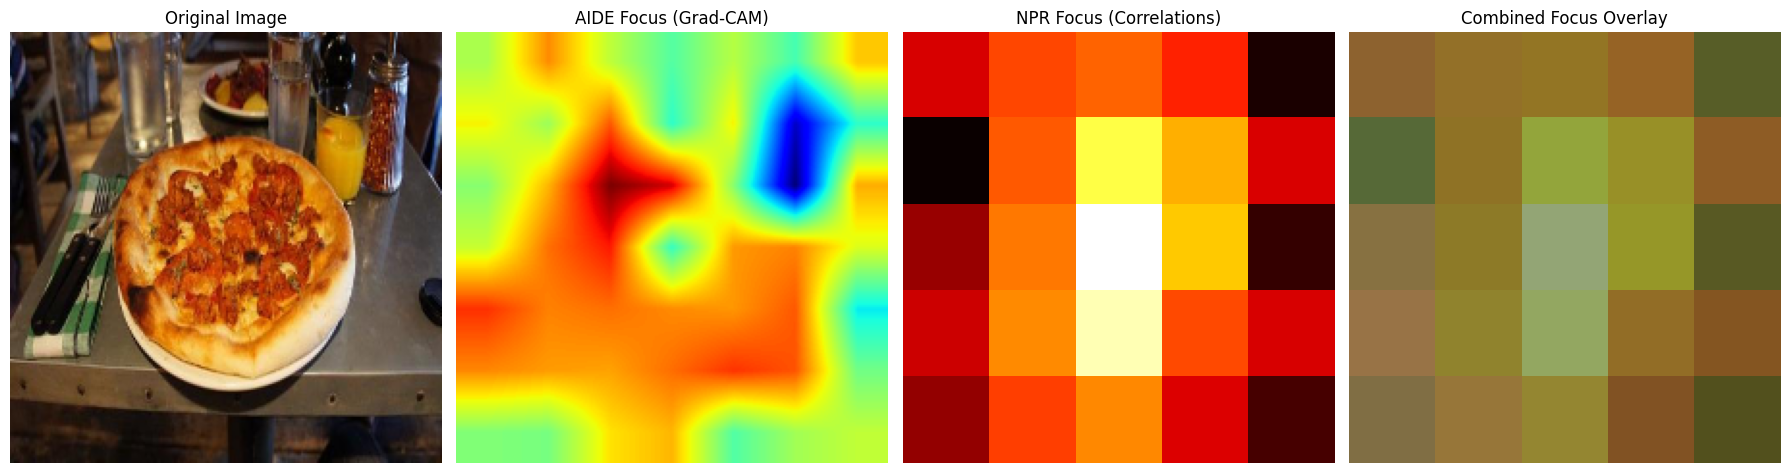

Model focus regions displayed for both AIDE and NPR branches


In [ ]:
# Combined Focus Regions Display
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

img = sample_img[0].cpu().detach().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = img * std + mean
img = np.clip(img, 0, 1)

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title("AIDE Focus (Grad-CAM)")
axes[1].axis("off")

axes[2].imshow(corr_heatmap, cmap='hot')
axes[2].set_title("NPR Focus (Correlations)")
axes[2].axis("off")

axes[3].imshow(img)
axes[3].imshow(heatmap, cmap='jet', alpha=0.4)
axes[3].imshow(corr_heatmap, cmap='hot', alpha=0.3)
axes[3].set_title("Combined Focus Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()
print("Model focus regions displayed for both AIDE and NPR branches")

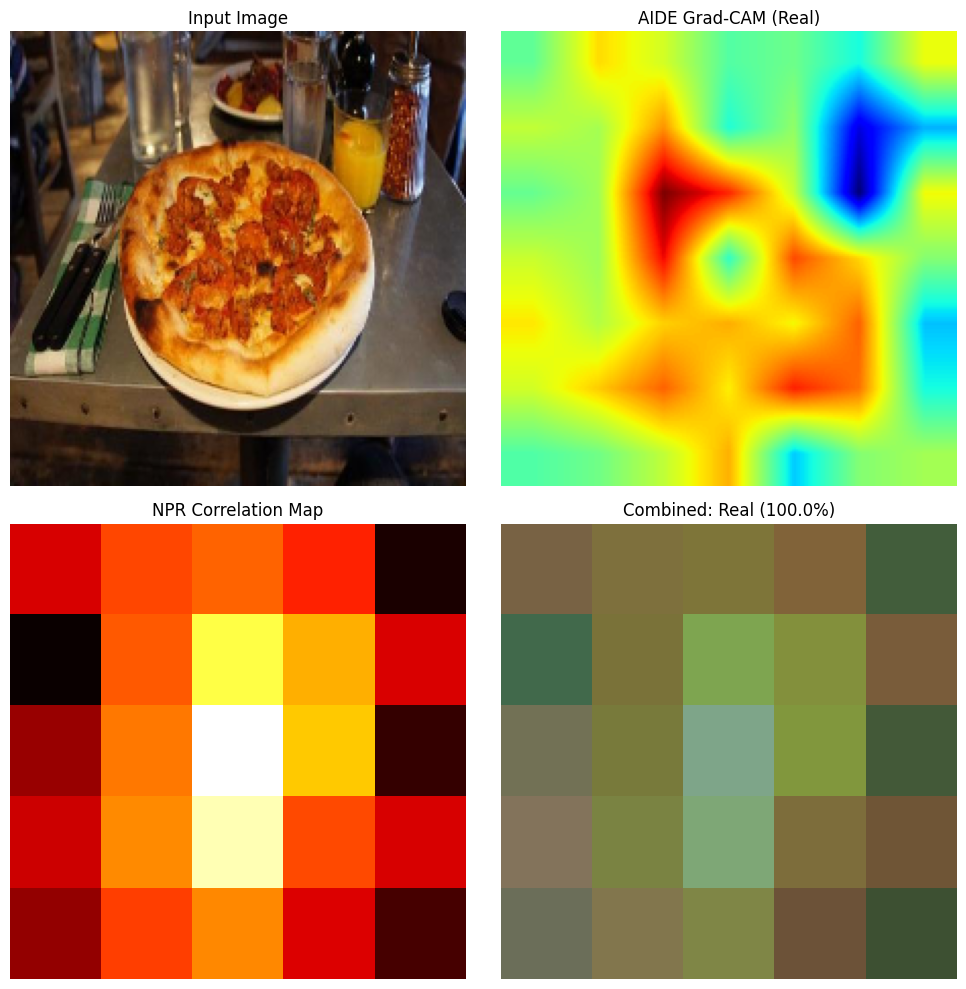

Final Prediction: Real (100.0%)


In [ ]:
# Combined Visualization with Prediction
def visualize_prediction(image_tensor, model_aide, model_npr, target_layer):
    heatmap, pred_class = grad_cam_aide(model_aide, image_tensor, target_layer)
    corr_heatmap = npr_correlation_heatmap(model_npr, image_tensor)

    features_combined = get_combined_features(model_aide, model_npr, image_tensor)
    logits = ensemble_head(features_combined)
    probs = torch.softmax(logits, dim=1)
    confidence = probs[0][pred_class].item() * 100

    img = image_tensor[0].cpu().detach().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    labels = ["Real", "Fake"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Input Image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(heatmap, cmap='jet')
    axes[0, 1].set_title(f"AIDE Grad-CAM ({labels[pred_class]})")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(corr_heatmap, cmap='hot')
    axes[1, 0].set_title("NPR Correlation Map")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(img)
    axes[1, 1].imshow(heatmap, cmap='jet', alpha=0.4)
    axes[1, 1].imshow(corr_heatmap, cmap='hot', alpha=0.3)
    axes[1, 1].set_title(f"Combined: {labels[pred_class]} ({confidence:.1f}%)")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()
    return labels[pred_class], confidence

label, conf = visualize_prediction(sample_img, aide_model, npr_model, target_layer)
print(f"Final Prediction: {label} ({conf:.1f}%)")

In [ ]:
# Display Confidence Scores and Prediction Breakdown
def prediction_breakdown(image_tensor):
    _, aide_features = aide_model(image_tensor)
    npr_features = npr_model(image_tensor)
    combined = torch.cat([aide_features, npr_features], dim=1)
    logits = ensemble_head(combined)
    probs = torch.softmax(logits, dim=1)

    aide_logits, _ = aide_model(image_tensor)
    aide_probs = torch.softmax(aide_logits, dim=1)

    npr_logits = npr_model(image_tensor)
    npr_probs = torch.softmax(npr_logits, dim=1)

    labels = ["Real", "Fake"]
    print("=" * 40)
    print("PREDICTION BREAKDOWN")
    print("=" * 40)

    print("\nAIDE Branch (CLIP-ViT):")
    for i, label in enumerate(labels):
        print(f"  {label}: {aide_probs[0][i]*100:.1f}%")

    print("\nNPR Branch (Pixel Correlation):")
    for i, label in enumerate(labels):
        print(f"  {label}: {npr_probs[0][i]*100:.1f}%")

    print("\nEnsemble (Combined):")
    for i, label in enumerate(labels):
        print(f"  {label}: {probs[0][i]*100:.1f}%")

    final_pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][final_pred].item() * 100

    print(f"\nFINAL DECISION: {labels[final_pred]} ({confidence:.1f}%)")
    print("=" * 40)

prediction_breakdown(sample_img)

PREDICTION BREAKDOWN

AIDE Branch (CLIP-ViT):
  Real: 99.9%
  Fake: 0.1%

NPR Branch (Pixel Correlation):
  Real: 1.2%
  Fake: 1.2%

Ensemble (Combined):
  Real: 100.0%
  Fake: 0.0%

FINAL DECISION: Real (100.0%)


In [ ]:
# Phase 7: Cross-Dataset Testing on Unseen Generators
def test_on_generator(model_aide, model_npr, ensemble_head, generator_path, generator_name, transform=val_transforms):
    real_path = os.path.join(generator_path, "real")
    fake_path = os.path.join(generator_path, "fake")

    images = []
    labels = []

    for img_name in os.listdir(real_path):
        images.append(os.path.join(real_path, img_name))
        labels.append(0)
    for img_name in os.listdir(fake_path):
        images.append(os.path.join(fake_path, img_name))
        labels.append(1)

    correct = 0
    total = 0

    for img_path, label in zip(images, labels):
        image = Image.open(img_path).convert("RGB")
        img_tensor = transform(image=np.array(image))["image"].unsqueeze(0).to(device)

        with torch.no_grad():
            _, aide_features = model_aide(img_tensor)
            npr_features = model_npr(img_tensor)
            combined = torch.cat([aide_features, npr_features], dim=1)
            outputs = ensemble_head(combined)
            pred = torch.argmax(outputs, dim=1).item()

        if pred == label:
            correct += 1
        total += 1

    accuracy = 100 * correct / total
    print(f"  {generator_name}: {accuracy:.2f}% ({correct}/{total})")
    return accuracy

base_path = "/root/.cache/kagglehub/datasets/putriaziza/deepguarddb-v1/versions/1/DeepGuardDB_v1"
generators = ["IMAGEN_dataset", "SD_dataset", "DALLE_dataset", "GLIDE_dataset"]

print("Testing on all generators:")
for gen in generators:
    gen_path = os.path.join(base_path, gen)
    test_on_generator(aide_model, npr_model, ensemble_head, gen_path, gen)

Testing on all generators:
  IMAGEN_dataset: 99.36% (2335/2350)
  SD_dataset: 99.44% (5320/5350)
  DALLE_dataset: 99.30% (4270/4300)
  GLIDE_dataset: 99.80% (998/1000)


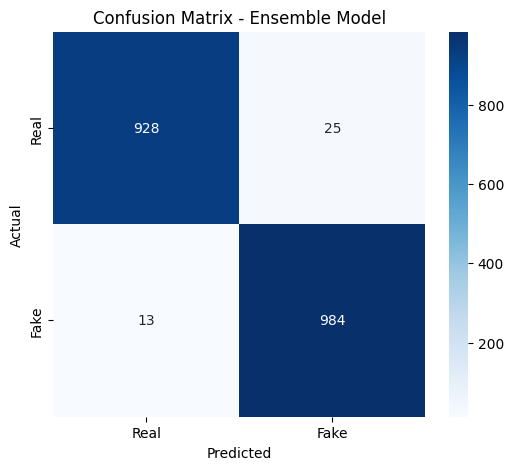


Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98       953
        Fake       0.98      0.99      0.98       997

    accuracy                           0.98      1950
   macro avg       0.98      0.98      0.98      1950
weighted avg       0.98      0.98      0.98      1950



In [ ]:
# Confusion Matrix for Ensemble Model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []

aide_model.eval()
npr_model.eval()
ensemble_head.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, aide_features = aide_model(images)
        npr_features = npr_model(images)
        combined = torch.cat([aide_features, npr_features], dim=1)
        outputs = ensemble_head(combined)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble Model')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

In [ ]:
# Test on Unseen Real-World Images
import requests
from PIL import Image
from io import BytesIO

def predict_unseen(image_path_or_url, name):
    try:
        if image_path_or_url.startswith("http"):
            response = requests.get(image_path_or_url)
            image = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            image = Image.open(image_path_or_url).convert("RGB")

        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            _, aide_features = aide_model(img_tensor)
            npr_features = npr_model(img_tensor)
            combined = torch.cat([aide_features, npr_features], dim=1)
            logits = ensemble_head(combined)
            probs = torch.softmax(logits, dim=1)

        pred = torch.argmax(probs, dim=1).item()
        conf = probs[0][pred].item() * 100
        labels = ["Real", "Fake"]

        print(f"{name}: {labels[pred]} ({conf:.1f}%)")
        return pred
    except Exception as e:
        print(f"{name}: Failed - {e}")

print("Testing on unseen real-world images...")
print("-" * 50)

predict_unseen("https://images.unsplash.com/photo-1507146426996-ef05306b995a", "Unsplash dog")
predict_unseen("https://images.unsplash.com/photo-1504208434309-cb69f4fe52b0", "Unsplash animal")
predict_unseen("https://upload.wikimedia.org/wikipedia/commons/thumb/4/4f/Dall-e_3_example_of_AI-generated_image.jpg/640px-Dall-e_3_example_of_AI-generated_image.jpg", "DALL-E image")
predict_unseen("https://images.unsplash.com/photo-1564349683136-77e08dba1ef7", "Unsplash panda")

Testing on unseen real-world images...
--------------------------------------------------
Unsplash dog: Fake (100.0%)
Unsplash animal: Fake (100.0%)
DALL-E image: Failed - cannot identify image file <_io.BytesIO object at 0x7fa875b8ad90>
Unsplash panda: Fake (100.0%)


1